In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


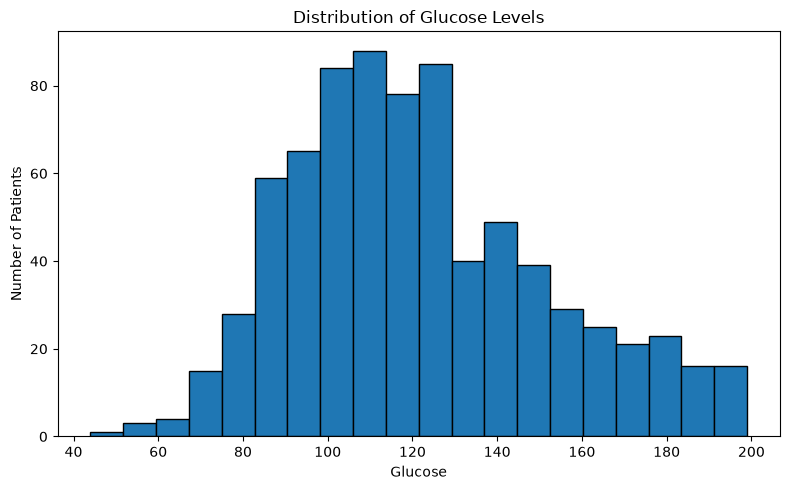

In [ ]:
# Graph 1: Glucose Distribution

import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv",
    names=columns
)

# Replace invalid zero glucose values with the median
df["Glucose"] = df["Glucose"].replace(0, pd.NA)
df["Glucose"] = df["Glucose"].fillna(df["Glucose"].median())

# Plot
plt.figure(figsize=(8, 5))

plt.hist(df["Glucose"], bins=20, edgecolor="black")

plt.title("Distribution of Glucose Levels")
plt.xlabel("Glucose")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

#The histogram shows the distribution of glucose levels among the patients.
# Most observations are concentrated around the middle range, while fewer patients have very low or very high glucose values. 
# Glucose is an important variable for understanding diabetes outcomes.

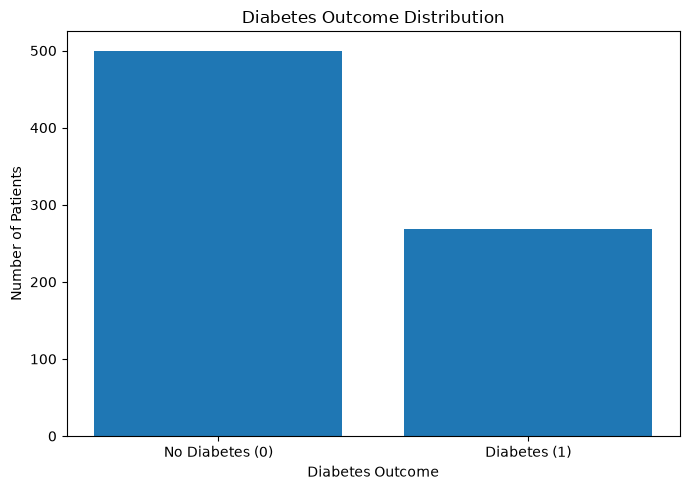

In [ ]:
# Graph 2: Diabetes Outcome Count

outcome_counts = df["Outcome"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    ["No Diabetes (0)", "Diabetes (1)"],
    outcome_counts.values
)

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Diabetes Outcome")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

#graph shows the number of patients classified as non-diabetic and diabetic. 
# There are more patients with Outcome = 0 than Outcome = 1, so the dataset is not evenly balanced between the two outcome groups.

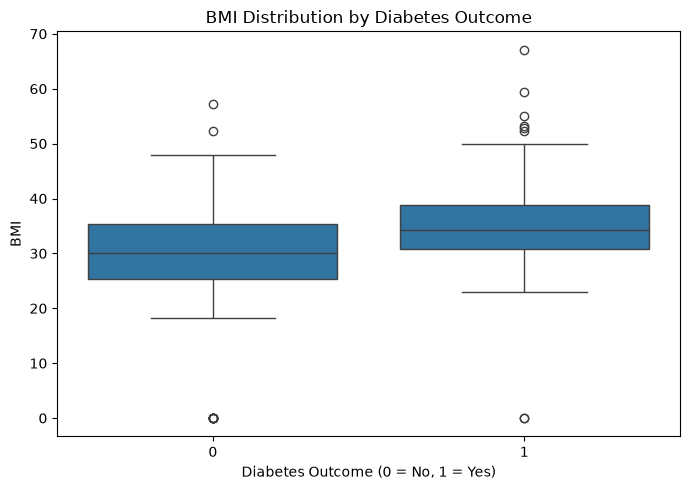

In [ ]:
# Graph 3: BMI by Diabetes Outcome

plt.figure(figsize=(7, 5))

sns.boxplot(
    x="Outcome",
    y="BMI",
    data=df
)

plt.title("BMI Distribution by Diabetes Outcome")
plt.xlabel("Diabetes Outcome (0 = No, 1 = Yes)")
plt.ylabel("BMI")

plt.tight_layout()
plt.show()
# The boxplot allows us to compare BMI between diabetic and non-diabetic patients.
#  The diabetic group generally shows a higher BMI distribution, suggesting that higher BMI may be associated with diabetes in this dataset. 
#However, the graph shows an association and does not prove that BMI causes diabetes.

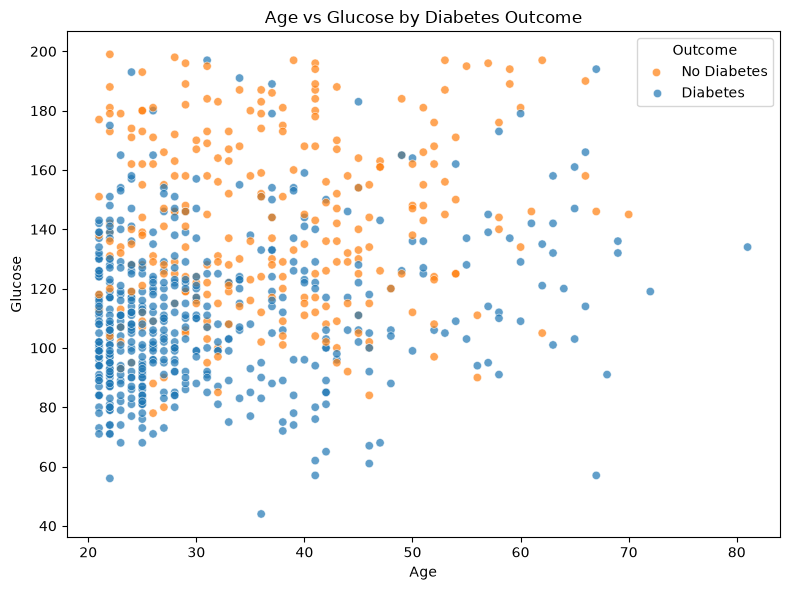

In [ ]:
# Graph 4: Age vs Glucose by Diabetes Outcome

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Glucose",
    hue="Outcome",
    alpha=0.7
)

plt.title("Age vs Glucose by Diabetes Outcome")
plt.xlabel("Age")
plt.ylabel("Glucose")
plt.legend(title="Outcome", labels=["No Diabetes", "Diabetes"])

plt.tight_layout()
plt.show()
#The scatter plot compares age and glucose levels while separating patients according to diabetes outcome.
#  Diabetic observations appear more frequently at higher glucose levels, while the distribution of glucose also varies across age groups.
#  This helps visualize how two important health factors relate to diabetes outcome.

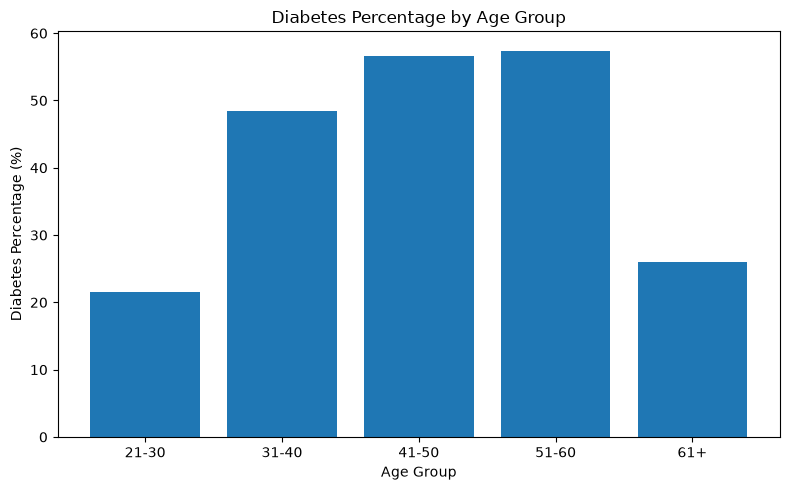

In [8]:
# Graph 5: Diabetes Percentage by Age Group

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[20, 30, 40, 50, 60, 100],
    labels=["21-30", "31-40", "41-50", "51-60", "61+"],
    right=True
)

diabetes_by_age = (
    df.groupby("AgeGroup", observed=False)["Outcome"]
      .mean() * 100
)

plt.figure(figsize=(8, 5))

plt.bar(
    diabetes_by_age.index.astype(str),
    diabetes_by_age.values
)

plt.title("Diabetes Percentage by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Diabetes Percentage (%)")

plt.tight_layout()
plt.show()
#The graph shows the percentage of patients with diabetes within each age group. 
# It helps identify whether diabetes occurrence differs across age categories. 
# The older age groups can be compared with younger groups to observe changes in diabetes prevalence

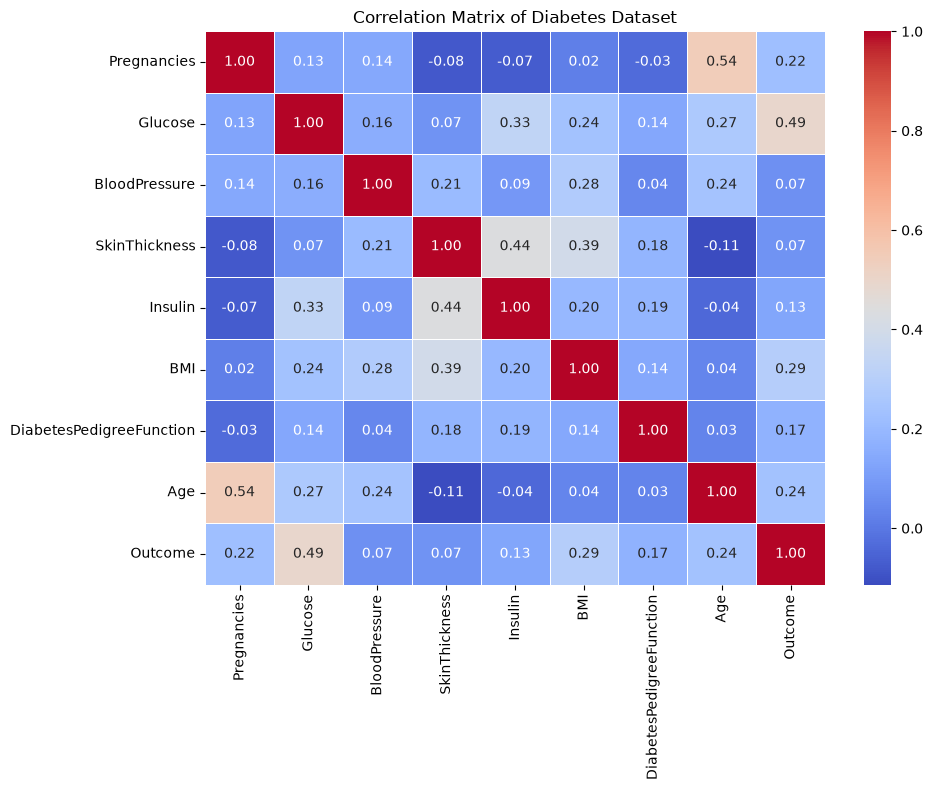

In [ ]:
# Graph 6: Correlation Matrix

plt.figure(figsize=(10, 8))

correlation_matrix = df.drop(columns=["AgeGroup"], errors="ignore").corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Diabetes Dataset")

plt.tight_layout()
plt.show()
#The correlation matrix shows the strength and direction of relationships between the numerical variables.
#  Values closer to +1 indicate a stronger positive relationship, values closer to -1 indicate a stronger negative relationship, 
# and values near 0 indicate a weak linear relationship.
#  It provides an overall view of which variables are most closely related to each other and to the diabetes outcome.